Method 1: SPINN (ours, Niazi et al. 2025)

# Set device

In [ ]:
import torch
import os

# Set device - Check for TPU, then CUDA (NVIDIA), then MPS (Apple Silicon), then CPU
if 'COLAB_TPU_ADDR' in os.environ:
    print("TPU runtime detected.")
    try:
        import torch_xla.core.xla_model as xm # type: ignore
        device = xm.xla_device()
        print(f"Using device: {device} (TPU)")
    except ImportError:
        print("torch_xla not found. Falling back to CPU.")
        device = torch.device("cpu")
        print(f"Using device: {device}")
        
elif torch.cuda.is_available():
    # NVIDIA GPU
    device = torch.device("cuda")
    print(f"Using device: {device} (NVIDIA GPU)")
    
elif torch.backends.mps.is_available():
    # Apple Silicon GPU (Mac M1/M2/M3/M4)
    device = torch.device("mps")
    print(f"Using device: {device} (Apple Metal GPU)")
    
else:
    # Default fallback
    device = torch.device("cpu")
    print(f"Using device: {device} (CPU)")

Using device: mps (Apple Metal GPU)


# System definitions

In [ ]:
import torch
import numpy as np


# --- Oscillators and chaotic systems ---

# Reverse Duffing (Nonlinear Oscillator)
# Used to study bistability and resonance phenomena in mechanical engineering. 
# Duffing models are used to design micro-electromechanical systems (MEMS), vibration isolators, 
# and mechanical energy harvesters that exploit nonlinear resonance to generate power from ambient vibrations.
class ReverseDuffing:
    def __init__(self):
        self.n_x = 2
        self.n_y = 1
        self.name = "ReverseDuffing"
        self.x0_space_bounds = [(-1.0, 1.0), (-1.0, 1.0)] 
        self.x_space_bounds = [(-2.0, 2.0), (-2.0, 2.0)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = x2**3
        dx2_dt = -x1
        return [dx1_dt, dx2_dt]

    def h(self, x):
        return x[..., 0:1]  # y = x_1

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Van der Pol Oscillator
# Used in biology to model autonomous rhythms like the spiking of neurons, 
# the beating of the human heart, and circadian clocks, as well as in acoustic modeling for the vocal cords.
class VanDerPol:
    def __init__(self, mu=3.0):
        self.n_x = 2
        self.n_y = 1
        self.name = "VanDerPol"
        self.mu = mu
        self.x0_space_bounds = [(-3.0, 3.0), (-3.0, 3.0)] 
        self.x_space_bounds = [(-5.0, 5.0), (-8.0, 8.0)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = x2
        dx2_dt = self.mu * (1 - x1**2) * x2 - x1
        return [dx1_dt, dx2_dt]

    def h(self, x):
        return x[..., 0:1] # y = x_1

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Rössler System
# Purely mathematical benchmark
class Rossler:
    def __init__(self, a=0.2, b=0.2, c=5.7):
        self.n_x = 3
        self.n_y = 1
        self.name = "Rossler"
        self.a, self.b, self.c = a, b, c
        self.x0_space_bounds = [(-5.0, 5.0), (-5.0, 5.0), (0.0, 5.0)]
        self.x_space_bounds = [(-10.0, 10.0), (-10.0, 10.0), (0.0, 20.0)]

    def f(self, t, x):
        x1, x2, x3 = x
        dx1_dt = -x2 - x3
        dx2_dt = x1 + self.a * x2
        dx3_dt = self.b + x3 * (x1 - self.c)
        return [dx1_dt, dx2_dt, dx3_dt]

    def h(self, x):
        return x[..., 1:2] # y = x_2

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Lorenz System
# Used in weather forecasting, data assimilation limits, in secure communications (chaotic cryptography).
class Lorenz:
    def __init__(self, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
        self.n_x = 3
        self.n_y = 1
        self.name = "Lorenz"
        self.sigma, self.rho, self.beta = sigma, rho, beta
        self.x0_space_bounds = [(-10.0, 10.0), (-20.0, 20.0), (0.0, 30.0)]
        self.x_space_bounds = [(-20.0, 20.0), (-30.0, 30.0), (0.0, 50.0)]

    def f(self, t, x):
        x1, x2, x3 = x
        dx1_dt = self.sigma * (x2 - x1)
        dx2_dt = x1 * (self.rho - x3) - x2
        dx3_dt = x1 * x2 - self.beta * x3
        return [dx1_dt, dx2_dt, dx3_dt]

    def h(self, x):
        return x[..., 1:2] # y = x_2

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Chua's Circuit
# Used to study chaotic phenomena and bifurcation routing in electronic circuits.
class ChuasCircuit:
    def __init__(self, alpha=15.6, beta=28.0, m0=-1.143, m1=-0.714):
        self.n_x = 3
        self.n_y = 1
        self.name = "ChuasCircuit"
        self.alpha, self.beta = alpha, beta
        self.m0, self.m1 = m0, m1
        self.x0_space_bounds = [(-2.0, 2.0), (-2.0, 2.0), (-2.0, 2.0)]
        self.x_space_bounds = [(-5.0, 5.0), (-5.0, 5.0), (-5.0, 5.0)]

    def f(self, t, x):
        x1, x2, x3 = x
        # Piecewise nonlinear electrical response
        g_x1 = self.m1 * x1 + 0.5 * (self.m0 - self.m1) * (abs(x1 + 1.0) - abs(x1 - 1.0))
        dx1_dt = self.alpha * (x2 - x1 - g_x1)
        dx2_dt = x1 - x2 + x3
        dx3_dt = -self.beta * x2
        return [dx1_dt, dx2_dt, dx3_dt]

    def h(self, x):
        return x[..., 0:1]  # y = x_1 (voltage across capacitor C1)

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Chen System
# Used as a target system for testing the anti-control of chaos 
# and designing complex masking signals for secure communications.
class ChenSystem:
    def __init__(self, a=35.0, b=3.0, c=28.0):
        self.n_x = 3
        self.n_y = 1
        self.name = "ChenSystem"
        self.a, self.b, self.c = a, b, c
        self.x0_space_bounds = [(-10.0, 10.0), (-10.0, 10.0), (-10.0, 10.0)]
        self.x_space_bounds = [(-30.0, 30.0), (-30.0, 30.0), (-30.0, 30.0)]

    def f(self, t, x):
        x1, x2, x3 = x
        dx1_dt = self.a * (x2 - x1)
        dx2_dt = (self.c - self.a) * x1 - x1 * x3 + self.c * x2
        dx3_dt = x1 * x2 - self.b * x3
        return [dx1_dt, dx2_dt, dx3_dt]

    def h(self, x):
        return x[..., 1:2]  # y = x_2

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Double Pendulum
# Used in classical mechanics to study deterministic chaos 
# and the limits of state estimation in highly sensitive conservative systems.
class DoublePendulum:
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
        self.n_x = 4
        self.n_y = 2
        self.name = "DoublePendulum"
        self.m1, self.m2 = m1, m2
        self.l1, self.l2 = l1, l2
        self.g = g
        # x = [theta1, theta2, omega1, omega2]
        self.x0_space_bounds = [(-np.pi/2, np.pi/2), (-np.pi/2, np.pi/2), (-1.0, 1.0), (-1.0, 1.0)]
        self.x_space_bounds = [(-np.pi, np.pi), (-np.pi, np.pi), (-5.0, 5.0), (-5.0, 5.0)]

    def f(self, t, x):
        x1, x2, x3, x4 = x
        delta = x1 - x2
        
        # Denominator to avoid implicit mass matrix inversion
        den = 2 * self.m1 + self.m2 - self.m2 * np.cos(2 * x1 - 2 * x2)
        
        dx1_dt = x3
        dx2_dt = x4
        
        dx3_dt = (-self.g * (2 * self.m1 + self.m2) * np.sin(x1) 
                  - self.m2 * self.g * np.sin(x1 - 2 * x2) 
                  - 2 * np.sin(delta) * self.m2 * (x4**2 * self.l2 + x3**2 * self.l1 * np.cos(delta))) / (self.l1 * den)
                  
        dx4_dt = (2 * np.sin(delta) * (x3**2 * self.l1 * (self.m1 + self.m2) 
                  + self.g * (self.m1 + self.m2) * np.cos(x1) 
                  + x4**2 * self.l2 * self.m2 * np.cos(delta))) / (self.l2 * den)
                  
        return [dx1_dt, dx2_dt, dx3_dt, dx4_dt]

    def h(self, x):
        return x[..., 0:2] # y = [theta1, theta2]

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    


# --- Power systems and networks ---

# Swing Equation (Synchronous Machine)
# Used to evaluate the transient stability and electromechanical rotor dynamics 
# of synchronous generators within interconnected power grids.
class SwingEquation:
    def __init__(self, M=0.0146, D=0.05, Pm=1.0, Pmax=2.0):
        self.n_x = 2
        self.n_y = 1
        self.name = "SwingEquation"
        self.M, self.D, self.Pm, self.Pmax = M, D, Pm, Pmax
        # x1 = rotor angle (radians), x2 = frequency deviation (rad/s)
        self.x0_space_bounds = [(0.0, np.pi), (-1.0, 1.0)]
        self.x_space_bounds = [(-np.pi, 2 * np.pi), (-5.0, 5.0)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = x2
        dx2_dt = (self.Pm - self.Pmax * np.sin(x1) - self.D * x2) / self.M
        return [dx1_dt, dx2_dt]

    def h(self, x):
        return x[..., 0:1]  # y = x_1 (measurable rotor angle)

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    

# Kuramoto Model
# Used to analyze conditions necessary for spontaneous phase synchronization 
# across complex networks of coupled, nonlinear oscillators.
class Kuramoto4:
    def __init__(self, K=2.0, omegas=[-1.0, -0.5, 0.5, 1.0]):
        self.n_x = 4
        self.n_y = 2
        self.name = "Kuramoto4"
        self.K = K
        self.omegas = omegas # Natural frequencies
        # Phases wrapped on the torus
        self.x0_space_bounds = [(-np.pi, np.pi)] * 4
        self.x_space_bounds = [(-2 * np.pi, 2 * np.pi)] * 4

    def f(self, t, x):
        x_all = x # [theta1, theta2, theta3, theta4]
        dx_dt = []
        for i in range(self.n_x):
            # Sum of phase differences from all oscillators to oscillator i
            coupling = sum(np.sin(xj - x_all[i]) for xj in x_all)
            dx_dt.append(self.omegas[i] + (self.K / self.n_x) * coupling)
        return dx_dt

    def h(self, x):
        return x[..., 0:2] # y = Observe phase of oscillators 1 and 2

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    

# Network Preserving Power Flow (Bergen-Hill)
# Used to model the topological stability of a power transmission network 
# by incorporating the structural dynamics of individual load buses.
class BergenHillPowerFlow:
    def __init__(self, M1=0.05, D1=0.02, D2=0.03, Pm1=1.5, Pd2=1.0, V1=1.0, V2=1.0, B12=2.5):
        self.n_x = 3
        self.n_y = 1
        self.name = "BergenHill"
        # 1 Generator node (2 states), 1 Load node (1 state)
        self.M1, self.D1, self.D2 = M1, D1, D2
        self.Pm1, self.Pd2 = Pm1, Pd2
        self.V1, self.V2, self.B12 = V1, V2, B12
        
        # x = [delta_gen, omega_gen, delta_load]
        self.x0_space_bounds = [(-0.5, 0.5), (-1.0, 1.0), (-0.5, 0.5)]
        self.x_space_bounds = [(-np.pi, np.pi), (-5.0, 5.0), (-np.pi, np.pi)]

    def f(self, t, x):
        x1, x2, x3 = x
        
        # Active power transfer over the line
        P12 = self.V1 * self.V2 * self.B12 * np.sin(x1 - x3)
        
        # Second-order generator dynamics
        dx1_dt = x2
        dx2_dt = (self.Pm1 - P12 - self.D1 * x2) / self.M1
        
        # First-order load dynamics
        dx3_dt = (-self.Pd2 + P12) / self.D2
        
        return [dx1_dt, dx2_dt, dx3_dt]

    def h(self, x):
        return x[..., 1:2] # y = omega_gen (Frequency is easily measurable)

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)



# --- Traffic system ---

# Intelligent Driver Model (IDM)
# Used to simulate microscopic, continuous-time car-following behavior 
# for evaluating individual vehicle trajectories and adaptive cruise control systems.
class IntelligentDriverModel:
    def __init__(self, v_lead=15.0, v0=30.0, T=1.5, a=0.73, b=1.67, delta=4.0, s0=2.0):
        self.n_x = 2
        self.n_y = 1
        self.name = "IDM"
        # Autonomous 2D formulation tracking headway (s) and follower velocity (v)
        # against a virtual leader driving at constant v_lead
        self.v_lead = v_lead
        self.v0, self.T, self.a, self.b = v0, T, a, b
        self.delta, self.s0 = delta, s0
        
        self.x0_space_bounds = [(10.0, 50.0), (0.0, 20.0)] 
        self.x_space_bounds = [(0.1, 100.0), (0.0, 35.0)]

    def f(self, t, x):
        s, v = x
        delta_v = v - self.v_lead
        
        # Desired dynamical headway
        s_star = self.s0 + np.maximum(0, v * self.T + (v * delta_v) / (2 * np.sqrt(self.a * self.b)))
        
        ds_dt = self.v_lead - v
        dv_dt = self.a * (1.0 - (v / self.v0)**self.delta - (s_star / (s + 1e-6))**2)
        
        return [ds_dt, dv_dt]

    def h(self, x):
        return x[..., 0:1] # y = headway distance

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)



# --- Game theory and distributed learning ---

# Replicator Dynamics
# Used in evolutionary game theory to describe how the distribution of 
# competing strategic behaviors evolves within a population over time.
class ReplicatorDynamics:
    def __init__(self):
        self.n_x = 3
        self.n_y = 2
        self.name = "ReplicatorRPS"
        # Rock-Paper-Scissors zero-sum dynamics on the 3D probability simplex
        self.x0_space_bounds = [(0.1, 0.8), (0.1, 0.8), (0.1, 0.8)]
        self.x_space_bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

    def f(self, t, x):
        x1, x2, x3 = x
        
        # Because the payoff matrix A is zero-sum, the average fitness phi is exactly 0.
        # This yields an elegant cubic nonlinearity.
        dx1_dt = x1 * (-x2 + x3)
        dx2_dt = x2 * (x1 - x3)
        dx3_dt = x3 * (-x1 + x2)
        
        return [dx1_dt, dx2_dt, dx3_dt]

    def h(self, x):
        return x[..., 0:2] # y = observe proportions of strategy 1 and 2

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        # Replicator dynamics must stay on the simplex (sum to 1)
        x_next = x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        return x_next / torch.sum(x_next, dim=-1, keepdim=True)


# Lotka-Volterra (Predator-Prey) Equations
# Used to capture the cyclical, nonlinear dynamics between competing 
# or interacting populations in biological, social, and economic ecosystems.
class LotkaVolterra:
    def __init__(self, alpha=1.5, beta=1.0, gamma=3.0, delta=1.0):
        self.n_x = 2
        self.n_y = 1
        self.name = "LotkaVolterra"
        self.alpha, self.beta = alpha, beta
        self.gamma, self.delta = gamma, delta
        # Strict positivity required for population dynamics
        self.x0_space_bounds = [(0.1, 5.0), (0.1, 5.0)]
        self.x_space_bounds = [(0.0, 10.0), (0.0, 10.0)]

    def f(self, t, x):
        x1, x2 = x
        dx1_dt = self.alpha * x1 - self.beta * x1 * x2
        dx2_dt = self.delta * x1 * x2 - self.gamma * x2
        return [dx1_dt, dx2_dt]

    def h(self, x):
        return x[..., 0:1]  # y = x_1 (observing prey population only)

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    


# --- Biomedical & Healthcare ---

# FitzHugh-Nagumo Model
# Used as a two-dimensional mathematical simplification of neural dynamics
# to study the bifurcation mechanisms behind spiking neurons.
class FitzHughNagumo:
    def __init__(self, a=0.7, b=0.8, c=3.0, I_ext=0.5):
        self.n_x = 2
        self.n_y = 1
        self.name = "FitzHughNagumo"
        self.a, self.b, self.c, self.I_ext = a, b, c, I_ext
        self.x0_space_bounds = [(-2.0, 2.0), (-2.0, 2.0)]
        self.x_space_bounds = [(-3.0, 3.0), (-3.0, 3.0)]

    def f(self, t, x):
        x1, x2 = x
        # x1 = membrane potential, x2 = recovery variable
        dx1_dt = self.c * (x1 - (x1**3) / 3.0 + x2 + self.I_ext)
        dx2_dt = -(x1 - self.a + self.b * x2) / self.c
        return [dx1_dt, dx2_dt]

    def h(self, x):
        return x[..., 0:1]  # y = x_1 (membrane potential is standard observable)

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    

# Hodgkin-Huxley Model
# Used to describe the nonlinear electrical characteristics of biological cell membranes
# and the propagation of action potentials via ion channels.
class HodgkinHuxley:
    def __init__(self, I_inj=10.0, C_m=1.0, g_K=36.0, g_Na=120.0, g_l=0.3, V_K=-12.0, V_Na=115.0, V_l=10.613):
        self.n_x = 4
        self.n_y = 1
        self.name = "HodgkinHuxley"
        # Shifted rest frame convention (resting potential ~ 0mV) for numerical stability
        self.I, self.Cm = I_inj, C_m
        self.gK, self.gNa, self.gl = g_K, g_Na, g_l
        self.VK, self.VNa, self.Vl = V_K, V_Na, V_l
        
        # x = [V, n (potassium activation), m (sodium activation), h (sodium inactivation)]
        self.x0_space_bounds = [(-10.0, 50.0), (0.2, 0.8), (0.0, 0.2), (0.1, 0.9)]
        self.x_space_bounds = [(-30.0, 120.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

    def f(self, t, x):
        V, n, m, h = x
        
        # Handling the removable singularities at V=10 and V=25 using np.where
        alpha_n = np.where(np.isclose(V, 10.0), 0.1, 0.01 * (10.0 - V) / (np.exp((10.0 - V) / 10.0) - 1.0))
        alpha_m = np.where(np.isclose(V, 25.0), 1.0, 0.1 * (25.0 - V) / (np.exp((25.0 - V) / 10.0) - 1.0))
        
        beta_n = 0.125 * np.exp(-V / 80.0)
        beta_m = 4.0 * np.exp(-V / 18.0)
        
        alpha_h = 0.07 * np.exp(-V / 20.0)
        beta_h = 1.0 / (np.exp((30.0 - V) / 10.0) + 1.0)
        
        dV_dt = (self.I - self.gK * (n**4) * (V - self.VK) - self.gNa * (m**3) * h * (V - self.VNa) - self.gl * (V - self.Vl)) / self.Cm
        dn_dt = alpha_n * (1.0 - n) - beta_n * n
        dm_dt = alpha_m * (1.0 - m) - beta_m * m
        dh_dt = alpha_h * (1.0 - h) - beta_h * h
        
        return [dV_dt, dn_dt, dm_dt, dh_dt]

    def h(self, x):
        return x[..., 0:1] # y = V (Membrane potential)

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# SEIR (Susceptible-Exposed-Infectious-Recovered) Model 
# Used to forecast the transmission dynamics and peak impact of infectious diseases 
# across compartmentalized populations to inform public healthcare interventions.
class SEIRModel:
    def __init__(self, beta=0.3, sigma=0.1, gamma=0.1):
        self.n_x = 4
        self.n_y = 1
        self.name = "SEIRModel"
        self.beta, self.sigma, self.gamma = beta, sigma, gamma
        # S, E, I, R represent fractions of the population, bounded [0, 1]
        self.x0_space_bounds = [(0.5, 0.9), (0.0, 0.1), (0.01, 0.1), (0.0, 0.1)]
        self.x_space_bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]

    def f(self, t, x):
        S, E, I, R = x
        dS_dt = -self.beta * S * I
        dE_dt = self.beta * S * I - self.sigma * E
        dI_dt = self.sigma * E - self.gamma * I
        dR_dt = self.gamma * I
        return [dS_dt, dE_dt, dI_dt, dR_dt]

    def h(self, x):
        # Tracking standard clinically observable data (Infectious population)
        return x[..., 2:3]

    def rk4_step(self, x, dt):
        k1 = torch.tensor(self.f(0, x.cpu().numpy()), dtype=x.dtype, device=x.device)
        k2 = torch.tensor(self.f(0, (x + 0.5 * dt * k1).cpu().numpy()), dtype=x.dtype, device=x.device)
        k3 = torch.tensor(self.f(0, (x + 0.5 * dt * k2).cpu().numpy()), dtype=x.dtype, device=x.device)
        k4 = torch.tensor(self.f(0, (x + dt * k3).cpu().numpy()), dtype=x.dtype, device=x.device)
        return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Helper functions

## MLP class

In [3]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims, activation=nn.ReLU):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims + [output_dim]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            # Check if activation is a class or an instance
            if isinstance(activation, nn.Module): # If it's already an instance
                 layers.append(activation)
            else: # Assume it's a class and instantiate it
                 layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Sample random points in X

In [4]:
import numpy as np
import torch

# sample_x0 accepts state space bounds directly
def sample_x0(bounds, n_samples):
    samples = []
    # Ensure bounds are in (min, max) format
    if isinstance(bounds, list) and isinstance(bounds[0], tuple):
        for (low, high) in bounds:
            samples.append(np.random.uniform(low, high, n_samples))
    else: # Fallback for simple (min, max) array
        low, high = bounds
        samples.append(np.random.uniform(low, high, (n_samples, len(low))))
        return samples[0]

    return np.stack(samples, axis=-1).squeeze()

# sample_x_points samples uniformly from a hyperrectangle defined by min_vals and max_vals
def sample_x_points(min_vals: torch.Tensor, max_vals: torch.Tensor, n_samples: int) -> torch.Tensor:
    n_dim = min_vals.shape[0]
    # Generate random numbers between 0 and 1
    rand_samples = torch.rand(n_samples, n_dim, device=min_vals.device)
    # Scale to desired range
    return min_vals + rand_samples * (max_vals - min_vals)

## Create observer matrices

In [ ]:
import numpy as np
import torch

def create_observer_matrices(n_z, n_y, system_name, strategy='diagonal', base_eig=-1.5, device='cpu'):
    """
    Creates a stable A matrix and a B matrix such that (A,B) is controllable.
    Eigenvalue spectrum [-2 * base_eig, -base_eig] to balance injectivity and floating-point precision.
    """
    if strategy == 'random_stable':
        print(f"Using densely coupled A (strict eigenvalues) and random B for {system_name}.")
        
        # 1. Sample eigenvalues strictly in the Goldilocks Zone (-3.0 to -1.5)
        # We use numpy for the QR decomposition as it is mathematically robust
        min_eig = -2.0 * base_eig
        max_eig = -1.0 * base_eig
        eigenvalues = np.random.uniform(min_eig, max_eig, size=n_z)
        D = np.diag(eigenvalues)
        
        # 2. Create a random orthogonal transformation matrix (Q)
        # This creates a dense, highly coupled A matrix without altering the eigenvalues
        H = np.random.randn(n_z, n_z)
        Q, R = np.linalg.qr(H)
        
        # 3. Calculate A = Q * D * Q^T
        A_np = Q @ D @ Q.T
        
        # 4. Generate a random dense B matrix (better for multi-dimensional outputs than ones)
        B_np = np.random.randn(n_z, n_y)
        
        # Cast to PyTorch tensors and push to the correct device
        A = torch.tensor(A_np, dtype=torch.float32, device=device)
        B = torch.tensor(B_np, dtype=torch.float32, device=device)

    elif strategy == 'diagonal':
         print(f"Using diagonal A and ones B for system {system_name}.")
         # Maintain legacy diagonal support if needed
         eigs = torch.linspace(base_eig, base_eig * 2, n_z)
         A = torch.diag(eigs).to(device)
         B = torch.ones((n_z, n_y)).to(device)

    else:
        print(f"Unknown matrix strategy '{strategy}'. Defaulting to diagonal A.")
        eigs = torch.linspace(base_eig, base_eig * 2, n_z)
        A = torch.diag(eigs).to(device)
        B = torch.ones((n_z, n_y)).to(device)

    return A, B

## Data normalization

In [ ]:
import numpy

# Data standardization / normalization

def scale_minmax(data, data_min, data_max):
    """Applies Min-Max scaling to [-1, 1]."""
    data_range = data_max - data_min
    data_range[data_range == 0] = 1e-8 # Avoid division by zero
    return 2.0 * (data - data_min) / data_range - 1.0

def unscale_minmax(scaled_data, data_min, data_max):
    """Applies inverse Min-Max scaling from [-1, 1]."""
    data_range = data_max - data_min
    data_range[data_range == 0] = 1e-8
    return (scaled_data + 1.0) / 2.0 * data_range + data_min

# SPINN method

## PDE loss function

In [7]:
import torch

# # --- PDE Loss Function ---

def pde_loss_fast(T_net, x_scaled, v_scaled, H_x_B, v_weights, A_obs, z_scale_factor, z_min):
    """
    Ultra-fast PDE loss that completely bypasses indexing and scale_minmax calculations.
    Requires precomputed H_x_B = h(x) @ B_obs.T and v_weights.
    """
    def t_net_batch(x): return T_net(x)
    
    # 1. Forward Pass and Jacobian-Vector Product in one highly optimized step
    z_pred_scaled, jvp_scaled = torch.func.jvp(t_net_batch, (x_scaled,), (v_scaled,))
    
    # 2. Inline Unscaling (Significantly faster than calling unscale_minmax functions)
    T_x_unscaled = (z_pred_scaled + 1.0) * z_scale_factor + z_min
    
    # 3. LHS: Scale the derivative to physical units
    pde_lhs_unscaled = jvp_scaled * z_scale_factor
    
    # 4. RHS: Physical dynamics (H_x_B is already precomputed!)
    pde_rhs_unscaled = torch.matmul(T_x_unscaled, A_obs.T) + H_x_B
    
    # 5. Residual Normalization
    residual_scaled = (pde_lhs_unscaled - pde_rhs_unscaled) / (z_scale_factor + 1e-8)
    
    return torch.mean(v_weights * (residual_scaled ** 2))

## Generate data

In [ ]:
import numpy as np
import torch

def generate_data_phase1(system, A, B, config, z_space_bounds, device='cpu'):
    n_trajs = config.get('n_trajs', 300)
    t_span = config.get('t_span', [0, 50])
    dt = config.get('dt', 0.01)
    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
    n_steps = len(t_eval)
        
    A_np = A.cpu().numpy() if isinstance(A, torch.Tensor) else A
    B_np = B.cpu().numpy() if isinstance(B, torch.Tensor) else B

    # 1. Vectorized Initial Conditions: Shape (dim, n_trajs) for fast broadcasting
    x_batch = np.random.uniform(
        low=[b[0] for b in system.x_space_bounds],
        high=[b[1] for b in system.x_space_bounds],
        size=(n_trajs, system.n_x)
    ).T 
        
    z_batch = np.random.uniform(
        low=[b[0] for b in z_space_bounds],
        high=[b[1] for b in z_space_bounds],
        size=(n_trajs, A_np.shape[0])
    ).T

    X_traj = np.zeros((n_steps, system.n_x, n_trajs))
    Z_traj = np.zeros((n_steps, A_np.shape[0], n_trajs))
        
    # 2. Vectorized RK4 Loop (Simulates 300 trajectories simultaneously)
    for i in range(n_steps):
        X_traj[i] = x_batch
        Z_traj[i] = z_batch
            
        # RK4 for physical system x
        k1_x = np.array(system.f(0, x_batch))
        k2_x = np.array(system.f(0, x_batch + 0.5 * dt * k1_x))
        k3_x = np.array(system.f(0, x_batch + 0.5 * dt * k2_x))
        k4_x = np.array(system.f(0, x_batch + dt * k3_x))
        x_next = x_batch + (dt / 6.0) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
            
        # RK4 for observer z
        def h_np(x_arr):
            return system.h(x_arr.T).T  # Output shape: (n_y, n_trajs)
            
        def z_f(z, y):
            return A_np @ z + B_np @ y
            
        k1_z = z_f(z_batch, h_np(x_batch))
        k2_z = z_f(z_batch + 0.5 * dt * k1_z, h_np(x_batch + 0.5 * dt * k1_x))
        k3_z = z_f(z_batch + 0.5 * dt * k2_z, h_np(x_batch + 0.5 * dt * k2_x))
        k4_z = z_f(z_batch + dt * k3_z, h_np(x_batch + dt * k3_x))
        z_next = z_batch + (dt / 6.0) * (k1_z + 2*k2_z + 2*k3_z + k4_z)
            
        x_batch = x_next
        z_batch = z_next

    # Transpose back to (n_trajs, n_steps, n_x)
    X_traj = X_traj.transpose(2, 0, 1) 
    Z_traj = Z_traj.transpose(2, 0, 1)
        
    # 3. Truncate transients (Drop first 20%)
    cutoff = int(0.2 * n_steps)
    X_reg_traj = X_traj[:, cutoff:, :] 
    Z_reg_traj = Z_traj[:, cutoff:, :]
    X_reg_np = X_traj[:, cutoff:, :].reshape(-1, system.n_x)
    Z_reg_np = Z_traj[:, cutoff:, :].reshape(-1, A_np.shape[0])
        
    # i. Calculate boundaries FIRST on the completely uncut dataset
    x_min = torch.tensor(X_reg_np.min(axis=0), dtype=torch.float32, device=device)
    x_max = torch.tensor(X_reg_np.max(axis=0), dtype=torch.float32, device=device)
    z_min = torch.tensor(Z_reg_np.min(axis=0), dtype=torch.float32, device=device)
    z_max = torch.tensor(Z_reg_np.max(axis=0), dtype=torch.float32, device=device)

    # ii. THEN Prevent Epoch Bloat via Subsampling
    max_reg_points = config.get('max_reg_points', 200000)
    if len(X_reg_np) > max_reg_points:
        idx = np.random.choice(len(X_reg_np), max_reg_points, replace=False)
        X_reg_sub = X_reg_np[idx]
        Z_reg_sub = Z_reg_np[idx]
    else:
        X_reg_sub = X_reg_np
        Z_reg_sub = Z_reg_np

    X_reg_torch = torch.tensor(X_reg_sub, dtype=torch.float32, device=device)
    Z_reg_torch = torch.tensor(Z_reg_sub, dtype=torch.float32, device=device)

    x_margin = 0.1 * torch.abs(x_max - x_min) + 1e-4
    x_min, x_max = x_min - x_margin, x_max + x_margin

    z_margin = 0.1 * torch.abs(z_max - z_min) + 1e-4
    z_min, z_max = z_min - z_margin, z_max + z_margin

    scaling_params = {'x_min': x_min, 'x_max': x_max, 'z_min': z_min, 'z_max': z_max}

    X_data_reg_scaled = scale_minmax(X_reg_torch, x_min, x_max)
    Z_data_reg_scaled = scale_minmax(Z_reg_torch, z_min, z_max)

    # Force the network to learn the physics in the OOD regions
    expansion_factor = config.get('expansion_factor', 1.5)
    
    # Expand outwards from the actual boundaries
    x_range = x_max - x_min
    x_pde_min = x_min - x_range * (expansion_factor - 1.0) / 2.0
    x_pde_max = x_max + x_range * (expansion_factor - 1.0) / 2.0

    # Pass the expanded bounds to the sampler
    n_points_forward = config.get('n_points_forward', 625000)
    x_pde_np = np.random.uniform(
        low=x_pde_min.cpu().numpy(),
        high=x_pde_max.cpu().numpy(),
        size=(n_points_forward, system.n_x)
    )
        
    v_pde_np = np.array(system.f(0, x_pde_np.T)).T

    x_pde_torch = torch.tensor(x_pde_np, dtype=torch.float32).to(device)
    v_pde_torch = torch.tensor(v_pde_np, dtype=torch.float32).to(device)

    X_reg_traj_torch = torch.tensor(X_reg_traj, dtype=torch.float32).to(device)
    Z_reg_traj_torch = torch.tensor(Z_reg_traj, dtype=torch.float32).to(device)
    return X_data_reg_scaled, Z_data_reg_scaled, x_pde_torch, v_pde_torch, X_reg_traj_torch, Z_reg_traj_torch, scaling_params


def simulate_z_batch(z0_corrupted, Z_true_traj, dt, A_torch):
    """
    Ultra-fast EXACT simulation exploiting linear error dynamics:
    Z_pert(t) = Z_true(t) + exp(A*t) * (Z_pert(0) - Z_true(0))
    """
    seq_len = Z_true_traj.shape[1]
    device = Z_true_traj.device
    
    # 1. Calculate the initial perturbation
    delta_z0 = z0_corrupted - Z_true_traj[:, 0, :] 
    
    # 2. Precompute the time steps (t)
    t_steps = torch.arange(seq_len, dtype=torch.float32, device=device) * dt
    
    # 3. Compute A * t for the whole sequence
    A_t = torch.einsum('ij,k->kij', A_torch, t_steps) 
    
    # 4. Compute the Matrix Exponential: e^{At}
    exp_A_t = torch.matrix_exp(A_t) 
    
    # 5. Decay the error exactly across time
    delta_z_t = torch.einsum('tij,bj->bti', exp_A_t, delta_z0) 
    
    # 6. Add the exact decayed error back to the true trajectory
    return Z_true_traj + delta_z_t


## Training function

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm # or 'from tqdm import tqdm'
from IPython.display import clear_output, display


def cycle_loader(dl):
    """Creates a zero-overhead infinite generator from a DataLoader."""
    while True:
        for batch in dl:
            yield batch



def train_spinn(system, A, B, config, z_space_bounds, device='cpu'):
    n_z = A.shape[0]
    n_y = B.shape[1]
    
    A_torch = torch.as_tensor(A, dtype=torch.float32).clone().detach().to(device)
    B_torch = torch.as_tensor(B, dtype=torch.float32).clone().detach().to(device)

    hidden_dims = config.get('hidden_dims', [100, 100, 100, 100])
    
    # Smooth activation functions
    activation_fn1 = config.get('activation1', nn.SiLU())
    activation_fn2 = config.get('activation2', nn.SiLU())
    
    t_net = MLP(system.n_x, n_z, hidden_dims, activation=activation_fn1).to(device)
    t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation_fn2).to(device)

    optimizer_phase1 = torch.optim.Adam(t_net.parameters(), lr=config.get('lr1', 1e-3))
    scheduler_phase1 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_phase1, T_max=config.get('epochs1', 100), eta_min=1e-6
    )
    
    optimizer_phase2 = torch.optim.Adam(t_inv_net.parameters(), lr=config.get('lr2', 1e-3))
    scheduler_phase2 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_phase2, T_max=config.get('epochs2', 1000), eta_min=1e-6
    )

    history_reg, history_pde, history_inv = [], [], []
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    plt.ion()

    # --- Phase 1: Train Forward Map T(x) ---
    print(f"--- Starting Phase 1 Training ({config.get('epochs1', 20)} epochs) ---")

    # Generate data
    X_reg, Z_reg, X_pde_unscaled, V_pde_unscaled, X_reg_traj, Z_reg_traj, scaling_params = generate_data_phase1(
        system, A, B, config, z_space_bounds, device
    )

    # True bounds in the x- and z-domains
    x_min, x_max = scaling_params['x_min'], scaling_params['x_max']
    z_min, z_max = scaling_params['z_min'], scaling_params['z_max']
    
    x_range = x_max - x_min
    z_range = z_max - z_min
    z_scale_factor = z_range / 2.0

    with torch.no_grad():
        X_pde_scaled = scale_minmax(X_pde_unscaled, x_min, x_max)
        V_pde_scaled = V_pde_unscaled * (2.0 / (x_range + 1e-8))
        
        # Evaluate system.h(x)
        h_x_unscaled = system.h(X_pde_unscaled) # Shape: (batch, n_y)
        if isinstance(h_x_unscaled, np.ndarray):
            h_x_unscaled = torch.tensor(h_x_unscaled, dtype=torch.float32, device=device)
        H_x_B_pde = torch.matmul(h_x_unscaled, B_torch.T)
        
        # Precompute the inverse velocity weights
        v_norm = torch.norm(V_pde_unscaled, dim=1, keepdim=True)
        V_weights = 1.0 / (v_norm + 1e-2)
        
    reg_dataset = TensorDataset(X_reg, Z_reg)
    reg_loader = DataLoader(reg_dataset, batch_size=config.get('batch_size_1', 256), shuffle=True)

    # Use the precomputed scaled tensors directly in the dataset
    pde_dataset = TensorDataset(X_pde_scaled, V_pde_scaled, H_x_B_pde, V_weights)
    pde_loader = DataLoader(pde_dataset, batch_size=config.get('batch_size_1', 256), shuffle=True)

    # lambda_reg = config.get('lambda_reg', 1.0)
    # lambda_pde = config.get('lambda_pde', 1.0)

    # Variable pde weight hyperparameter
    base_lambda_reg = config.get('lambda_reg', 1.0)
    base_lambda_pde = config.get('lambda_pde', 1.0)
    total_epochs1 = config.get('epochs1', 100)

    iterations_per_epoch_1 = max(len(reg_loader), len(pde_loader))
    
    # OPTIMIZATION: Zero-overhead infinite data generators
    reg_iter = cycle_loader(reg_loader)
    pde_iter = cycle_loader(pde_loader)

    for epoch in range(config.get('epochs1', 100)):
        epoch_reg_loss, epoch_pde_loss = 0.0, 0.0
        
        # --- DYNAMIC LOSS BALANCING ---
        # Ramp PDE loss from 1% up to 100% over the first half of training.
        # This lets the network learn the geometry first, then enforces physics.
        ramp_progress = min(1.0, epoch / (total_epochs1 * 0.5 + 1e-8))
        current_lambda_pde = base_lambda_pde * (0.01 + 0.99 * ramp_progress)
        current_lambda_reg = base_lambda_reg 
        # ------------------------------

        pbar = tqdm(range(iterations_per_epoch_1), desc=f"Phase 1 - Epoch {epoch}", leave=False)
        for _ in pbar:
            
            x_batch_reg_scaled, z_batch_reg_scaled = next(reg_iter)
            x_batch_pde_scaled, v_batch_pde_scaled, H_x_B_batch, v_weights_batch = next(pde_iter)

            # Regression Loss
            z_pred_scaled = t_net(x_batch_reg_scaled)
            loss_reg = torch.mean((z_pred_scaled - z_batch_reg_scaled) ** 2)
            
            # PDE Loss
            loss_pde = pde_loss_fast(
                t_net, x_batch_pde_scaled, v_batch_pde_scaled, 
                H_x_B_batch, v_weights_batch, 
                A_torch, z_scale_factor, z_min
            )

            # loss = lambda_reg * loss_reg + lambda_pde * loss_pde
            loss = current_lambda_reg * loss_reg + current_lambda_pde * loss_pde
            
            optimizer_phase1.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(t_net.parameters(), max_norm=1.0)
            optimizer_phase1.step()

            epoch_reg_loss += loss_reg.item()
            epoch_pde_loss += loss_pde.item()
            
            current_lr1 = optimizer_phase1.param_groups[0]['lr']
            pbar.set_postfix({'reg': f"{loss_reg.item():.2e}", 'pde': f"{loss_pde.item():.2e}", 'lr': f"{current_lr1:.2e}"})

        avg_reg = epoch_reg_loss / iterations_per_epoch_1
        avg_pde = epoch_pde_loss / iterations_per_epoch_1
        history_reg.append(avg_reg)
        history_pde.append(avg_pde)

        if epoch % 10 == 0 or epoch == config.get('epochs1', 100) - 1:
            ax1.clear()
            ax1.plot(history_reg, label='Reg Loss', color='blue', linewidth=1.5)
            ax1.plot(history_pde, label='PDE Loss', color='red', linewidth=1.5)
            ax1.set_yscale('log')
            ax1.set_title("Phase 1: Forward Map $T(x)$ Training Loss")
            ax1.set_xlabel("Epochs")
            ax1.set_ylabel("Mean Squared Error")
            ax1.grid(True, which="both", ls="--", alpha=0.5)
            ax1.legend()
            clear_output(wait=True)
            display(fig)

        print(f"Epoch {epoch} | Avg Reg Loss: {avg_reg:.4e} | Avg PDE Loss: {avg_pde:.4e} | PDE Wgt: {current_lambda_pde:.2f} | LR: {current_lr1:.2e}")
        scheduler_phase1.step()


    # --- Phase 2: Train Inverse Map T*(z) ---
    print(f"\n--- Starting Phase 2 Training ---")

    # Extract fully chronological sequences from the trajectory block
    n_trajs, n_steps_reg, _ = X_reg_traj.shape
    seq_len = config.get('seq_len', 10)
    num_seqs = n_steps_reg // seq_len

    X_seqs = X_reg_traj[:, :num_seqs * seq_len, :].reshape(-1, seq_len, system.n_x)
    Z_seqs = Z_reg_traj[:, :num_seqs * seq_len, :].reshape(-1, seq_len, n_z)

    # Scale X explicitly; keep Z unscaled for true physics injection
    X_seqs_scaled = scale_minmax(X_seqs, x_min, x_max)
    
    seq_dataset = TensorDataset(X_seqs_scaled, Z_seqs)
    phase2_loader = DataLoader(seq_dataset, batch_size=config.get('batch_size_2', 1024), shuffle=True)

    noise_base_std = 0.05 

    for epoch in range(config.get('epochs2', 1000)):
        epoch_inv_loss = 0.0
        # # Decay robustness requirement over time
        # Decay the noise linearly over a FIXED number of epochs (e.g., first 150 epochs)
        # This prevents the noise schedule from stretching if you increase total epochs.
        decay_horizon = 150 
        decay_factor = max(0.0, 1.0 - (epoch / decay_horizon))
        current_noise_pct = noise_base_std * decay_factor + 0.001

        pbar = tqdm(phase2_loader, desc=f"Phase 2 - Epoch {epoch}", leave=False)
        for X_batch_scaled, Z_batch_true_unscaled in pbar:
            
            with torch.no_grad():
                # Start strictly from the TRUE Z manifold generated in Phase 1
                z0_true_unscaled = Z_batch_true_unscaled[:, 0, :]
                
                # Apply tiny, physically scaled noise
                physical_noise = torch.randn_like(z0_true_unscaled) * current_noise_pct * z_range
                z0_corrupted_unscaled = z0_true_unscaled + physical_noise

                # Exact integration bypassing the RK4
                Z_traj_unscaled = simulate_z_batch(z0_corrupted_unscaled, Z_batch_true_unscaled, config['dt'], A_torch)

                # Rescale back to [-1, 1]
                Z_traj_scaled = scale_minmax(Z_traj_unscaled, z_min, z_max)
                
                # Widened soft-clamp to prevent flat-spotting
                Z_traj_scaled = torch.clamp(Z_traj_scaled, -2.5, 2.5)

            # Invert the sequence 
            X_pred_scaled = t_inv_net(Z_traj_scaled)
            loss_inv = torch.mean((X_pred_scaled - X_batch_scaled) ** 2)

            optimizer_phase2.zero_grad()
            loss_inv.backward()
            torch.nn.utils.clip_grad_norm_(t_inv_net.parameters(), max_norm=1.0)
            optimizer_phase2.step()

            epoch_inv_loss += loss_inv.item()
            pbar.set_postfix({'Traj MSE': f"{loss_inv.item():.2e}"})
        
        avg_inv = epoch_inv_loss / len(phase2_loader)
        history_inv.append(avg_inv)

        if epoch % 10 == 0 or epoch == config.get('epochs2', 1000) - 1:
            ax2.clear()
            ax2.plot(history_inv, label='Inv Loss', color='green')
            ax2.set_yscale('log')
            ax2.set_title("Phase 2: Inverse Map $T^*(z)$ Training Loss")
            ax2.grid(True, ls="--", alpha=0.5)
            ax2.legend()
            clear_output(wait=True)
            display(fig)
        
        print(f"Epoch {epoch} | Avg Loss: {avg_inv:.4e} | LR: {scheduler_phase2.get_last_lr()[0]:.2e}")
        scheduler_phase2.step()
        
    plt.close(fig)

    model_dict = {'t_net': t_net, 't_inv_net': t_inv_net}
    return model_dict, scaling_params

# Observer class

In [ ]:
import torch
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp


class Observer:
    def __init__(self, system, A_obs, B_obs, net, t0, tf, N, init_z_zero, scaling_params):
        """
        KKL Observer class

        Args:
            system: The system object (must have f, h, n_x, n_y).
            A_obs: The observer matrix A (torch tensor or numpy array) for system dynamics.
            B_obs: The observer matrix B (torch tensor or numpy array) for system dynamics.
            net: The neural network for the inverse transformation (T_inv_net).
                 (Assumes t_inv_net maps z_scaled -> x_scaled)
            t0: Start time of simulation.
            tf: End time of simulation.
            N: Number of time steps.
            init_z_zero: If True, initialize observer state z(0) to zero (unscaled).
            scaling_params: A dictionary containing min/max tensors for x, y, and z.
        """
        self.system = system
        self.A_obs = A_obs.clone().detach().to(device) if isinstance(A_obs, torch.Tensor) else torch.tensor(A_obs, dtype=torch.float32).to(device)
        self.B_obs = B_obs.clone().detach().to(device) if isinstance(B_obs, torch.Tensor) else torch.tensor(B_obs, dtype=torch.float32).to(device)
        self.net = net.to(device) # The inverse map (T_inv_net)

        self.t0 = t0
        self.tf = tf
        self.N = N
        self.dt = (tf - t0) / N
        self.t_eval_torch = torch.tensor(np.linspace(t0, tf, N + 1), dtype=torch.float32).to(device)

        self.init_z_zero = init_z_zero
        self._initial_z_unscaled = torch.zeros(self.A_obs.shape[0], dtype=torch.float32).to(device) if init_z_zero else None

        # Store scaling parameters
        self.x_min = scaling_params['x_min'].to(device)
        self.x_max = scaling_params['x_max'].to(device)
        self.z_min = scaling_params['z_min'].to(device)
        self.z_max = scaling_params['z_max'].to(device)
        self.y_min = scaling_params['y_min'].to(device)
        self.y_max = scaling_params['y_max'].to(device)

    def simulate(self, t_eval_torch, y_data_torch):
        """
        Simulates the KKL observer (z dynamics in UNSCALED space) and estimates x (unscaled).
        """
        n_z = self.A_obs.shape[0]
        n_y = self.system.n_y
        n_x = self.system.n_x

        # Initial condition for z observer
        z0_observer_unscaled = torch.zeros(n_z, dtype=torch.float32).to(device) if self.init_z_zero else self._initial_z_unscaled
        if z0_observer_unscaled is None:
            raise ValueError("Observer must be initialized with z(0) or init_z_zero=True")

        # Create an interpolator for the y_data
        y_data_np = y_data_torch.cpu().numpy()
        t_eval_np = t_eval_torch.cpu().numpy()

        # Use scipy.interpolate.interp1d for robust interpolation
        if n_y == 1:
            y_data_np_interp = y_data_np.squeeze(-1)
        else:
            y_data_np_interp = y_data_np

        y_interp_func_unscaled = interp1d(
            t_eval_np,
            y_data_np_interp,
            axis=0,
            kind='cubic', # linear/cubic
            bounds_error=False,
            fill_value="extrapolate"
        )

        # --- NumPy Z-Dynamics ---
        # Move matrices to CPU NumPy once to avoid dispatch latency inside the solver loop
        A_np = self.A_obs.cpu().numpy()
        B_np = self.B_obs.cpu().numpy()
        z0_np = z0_observer_unscaled.cpu().numpy()

        def observer_z_dynamics_np(t, z):
            # NumPy math, zero PyTorch overhead
            y_t = y_interp_func_unscaled(t)
            return A_np @ z + B_np @ np.atleast_1d(y_t)

        # Solve using the stiff-aware LSODA algorithm
        sol_z = solve_ivp(
            observer_z_dynamics_np,
            [t_eval_np[0], t_eval_np[-1]],
            z0_np,
            t_eval=t_eval_np,
            method='LSODA'
        )

        # Move the ENTIRE finished trajectory back to the device in one shot
        z_traj_torch_unscaled = torch.tensor(sol_z.y.T, dtype=torch.float32).to(device)


        # --- Network Gating (Batched Evaluation) ---
        # 1. Scale the entire Z trajectory
        z_traj_torch_scaled = scale_minmax(z_traj_torch_unscaled, self.z_min, self.z_max)

        # 2. Estimate scaled X in one massive parallel shot
        with torch.no_grad():
            x_hat_traj_torch_scaled = self.net(z_traj_torch_scaled)

        # 3. Unscale the estimated x trajectory
        x_hat_traj_torch_unscaled = unscale_minmax(x_hat_traj_torch_scaled, self.x_min, self.x_max)

        return z_traj_torch_unscaled, x_hat_traj_torch_unscaled

# Plotting function

In [ ]:
import torch
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


# --- Plotting Function ---

def simulate_and_plot(kkl_observer, x0_test_torch, title="KKL Observer Estimation", crop_transient=True):
    """
    Simulates the true system and the KKL observer and plots the results.

    Args:
        kkl_observer: An instance of the Observer class
        x0_test_torch: Initial condition for the true system simulation (torch tensor, shape (n_x,)).
        title: Title for the plot.
    """
    system = kkl_observer.system
    t_eval_torch = kkl_observer.t_eval_torch # Use the time points from the observer
    t_eval_np = t_eval_torch.cpu().numpy()

    # 1. Simulate the true system
    t_span = [kkl_observer.t0, kkl_observer.tf]
    x0_test_np = x0_test_torch.cpu().numpy().flatten()

    # sol = solve_ivp(system.f, t_span, x0_test_np, t_eval=t_eval_np, method='RK45')
    sol = solve_ivp(system.f, t_span, x0_test_np, t_eval=t_eval_np, method='LSODA')

    t_eval_true_np = sol.t
    x_true_np = sol.y.T # Shape (N+1, n_x)
    y_true_np = system.h(x_true_np) # Shape (N+1, n_y)


    # 2. Simulate the KKL observer
    # kkl_observer.simulate expects t_eval_torch and unscaled y_data_torch
    y_true_torch = torch.tensor(y_true_np, dtype=torch.float32).to(device)

    # simulate() returns (z_traj_torch_unscaled, x_hat_traj_torch_unscaled)
    z_hat_traj_unscaled, x_hat_traj_unscaled = kkl_observer.simulate(t_eval_torch, y_true_torch)

    # Convert estimated x trajectory to numpy for plotting
    x_hat_np_unscaled = x_hat_traj_unscaled.cpu().detach().numpy()


    # 3. Plot the results
    plt.figure(figsize=(12, 2 * system.n_x))

    for i in range(system.n_x):
        x_true_component = x_true_np[:, i]
        x_hat_component = x_hat_np_unscaled[:, i]

        plt.subplot(system.n_x, 1, i + 1)
        plt.plot(t_eval_true_np, x_true_component, 'k-', label=f'True x{i+1}')
        plt.plot(t_eval_true_np, x_hat_component, 'm--', label=f'Estimated x{i+1}')
        plt.ylabel(f'x{i+1}')
        plt.grid(True)
        plt.legend()

    plt.xlabel('Time')
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

# Run simulation

## Reverse Duffing oscillator

### Training

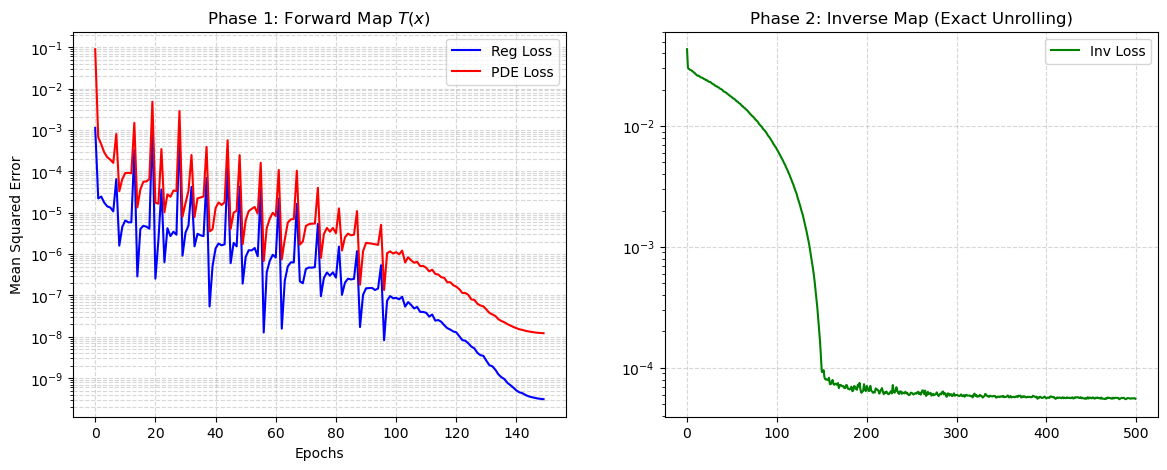

Epoch 499 | Avg Loss: 5.5521e-05 | LR: 1.01e-06

[SAVE] Successfully saved ReverseDuffing models to kkl_models_reverseduffing.pth

--- Simulating and Plotting Estimation ---


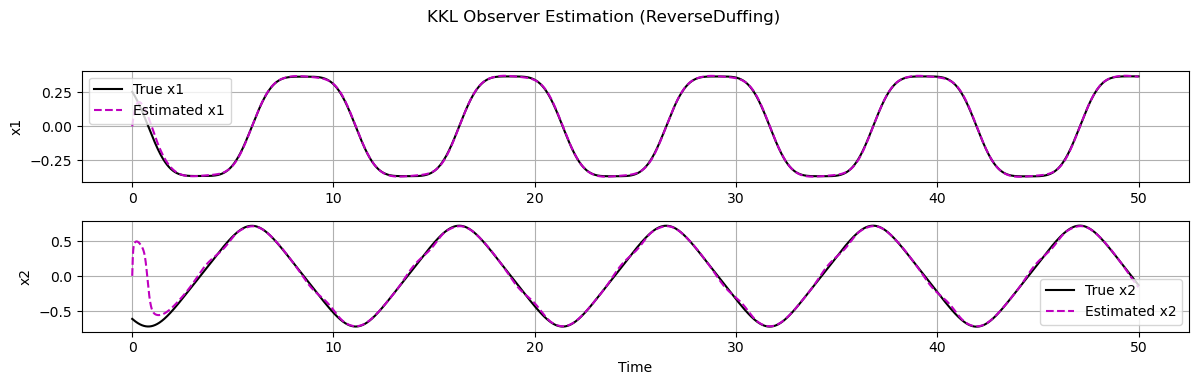


--- SPINN Method's Execution Complete ---


In [12]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = ReverseDuffing()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 200,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

--- Loading SPINN Model for Inference ---
Using diagonal A and ones B for system ReverseDuffing.
Successfully loaded checkpoint from kkl_models_reverseduffing.pth

--- Simulating and Plotting Estimation ---


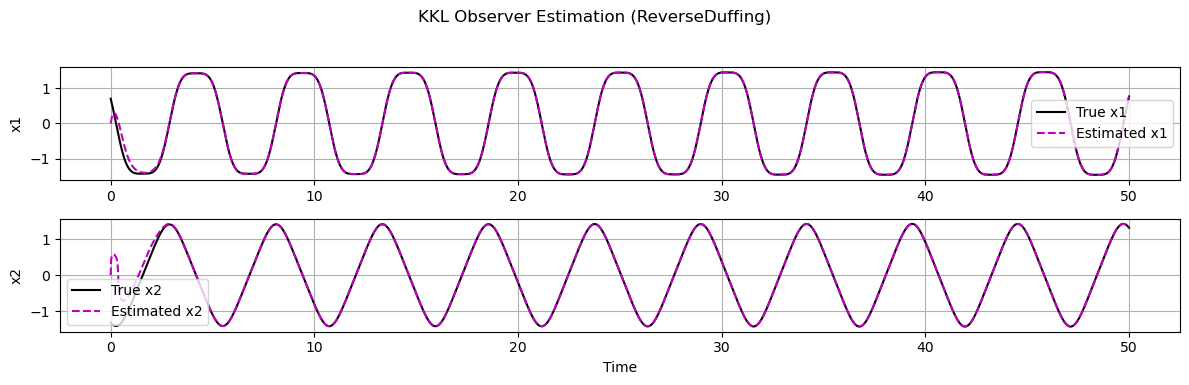


--- SPINN Method's Execution Complete ---


In [13]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = ReverseDuffing()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Van der Pol oscillator

### Training

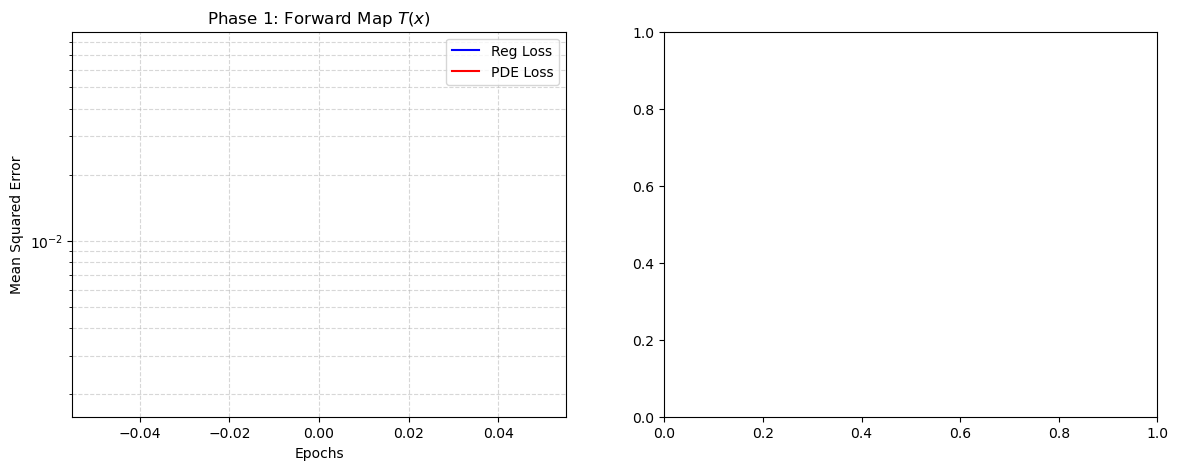

Epoch 0 | Avg Reg Loss: 1.8996e-03 | Avg PDE Loss: 7.4520e-02 | PDE Wgt: 0.01 | LR: 1.00e-03


Phase 1 - Epoch 1:   0%|          | 0/977 [00:00<?, ?it/s]

Epoch 1 | Avg Reg Loss: 3.6796e-04 | Avg PDE Loss: 1.0806e-02 | PDE Wgt: 0.02 | LR: 1.00e-03


Phase 1 - Epoch 2:   0%|          | 0/977 [00:00<?, ?it/s]

Epoch 2 | Avg Reg Loss: 2.1526e-04 | Avg PDE Loss: 6.8006e-03 | PDE Wgt: 0.04 | LR: 1.00e-03


Phase 1 - Epoch 3:   0%|          | 0/977 [00:00<?, ?it/s]

Epoch 3 | Avg Reg Loss: 1.4367e-04 | Avg PDE Loss: 4.3277e-03 | PDE Wgt: 0.05 | LR: 9.99e-04


Phase 1 - Epoch 4:   0%|          | 0/977 [00:00<?, ?it/s]

Epoch 4 | Avg Reg Loss: 8.7964e-05 | Avg PDE Loss: 2.2492e-03 | PDE Wgt: 0.06 | LR: 9.98e-04


Phase 1 - Epoch 5:   0%|          | 0/977 [00:00<?, ?it/s]

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = VanDerPol()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 300,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference


--- Simulating and Plotting Estimation ---


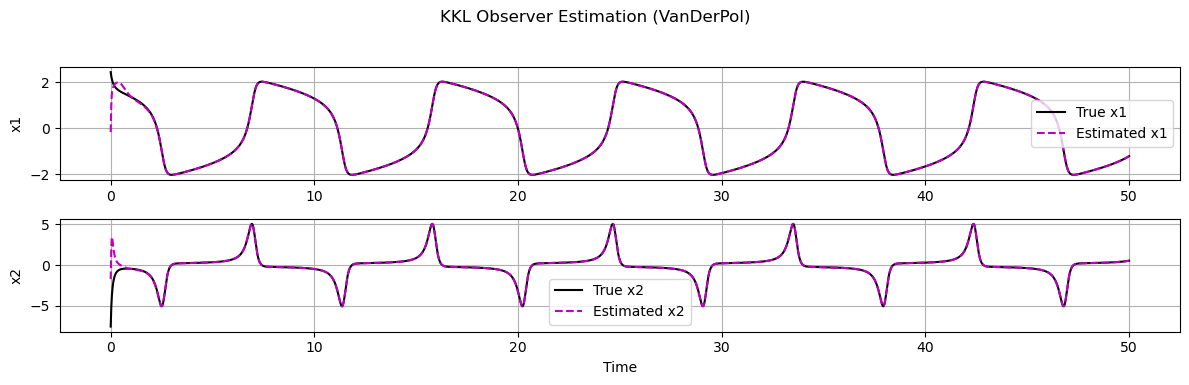


--- SPINN Method's Execution Complete ---


In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = VanDerPol()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Rossler system

### Training

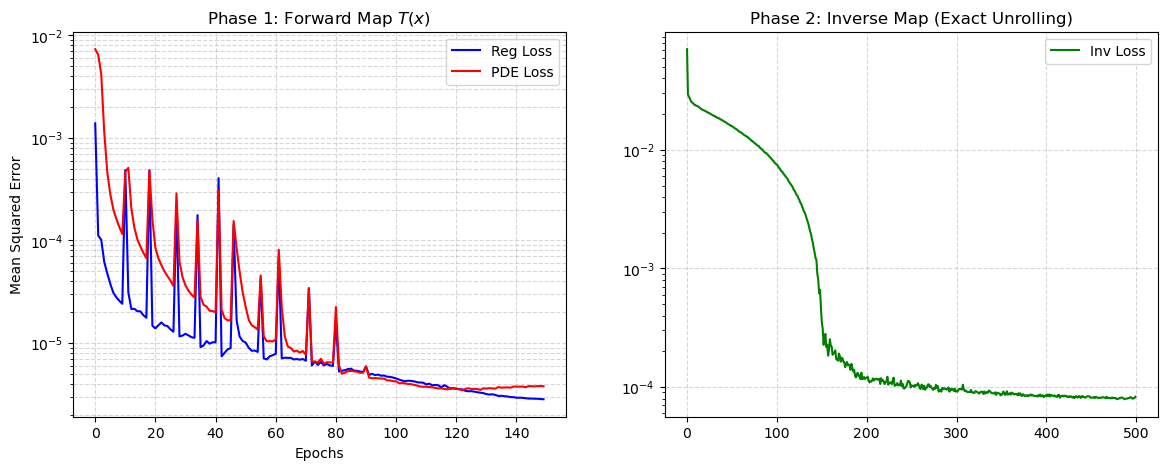

Epoch 499 | Avg Loss: 8.2890e-05 | LR: 1.01e-06

[SAVE] Successfully saved Rossler models to kkl_models_rossler.pth

--- Simulating and Plotting Estimation ---


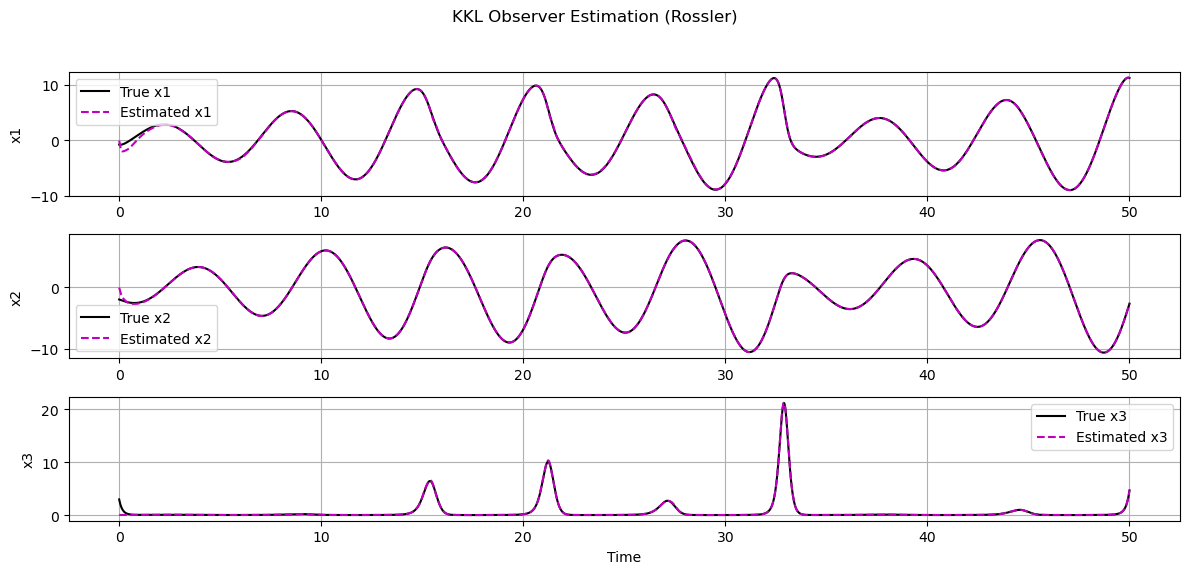


--- SPINN Method's Execution Complete ---


In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = Rossler()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference


--- Simulating and Plotting Estimation ---


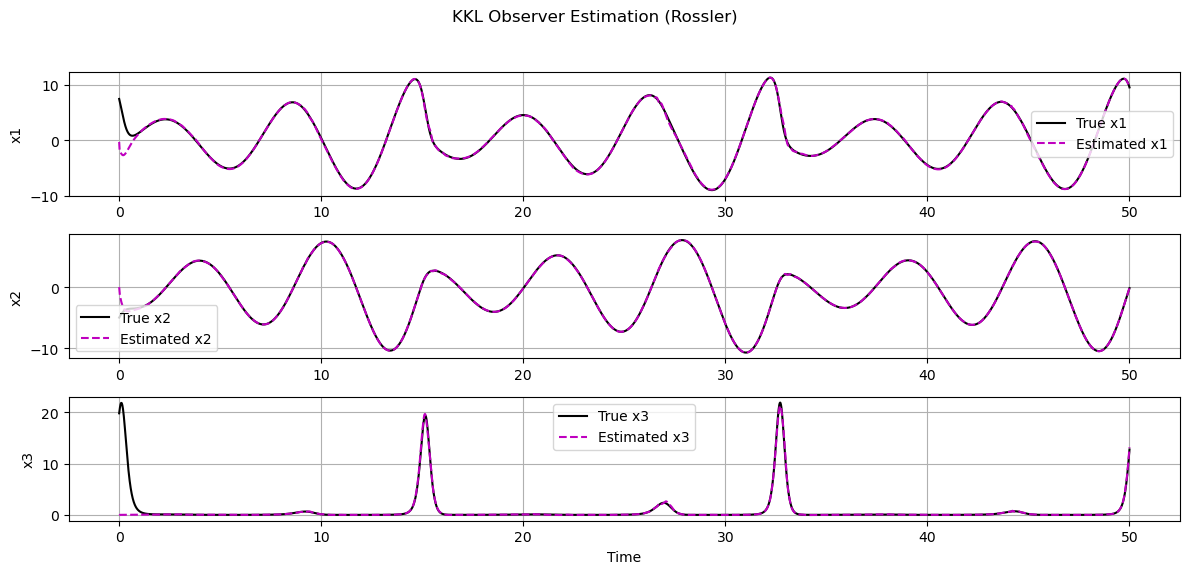


--- SPINN Method's Execution Complete ---


In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = Rossler()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Lorenz system

### Training

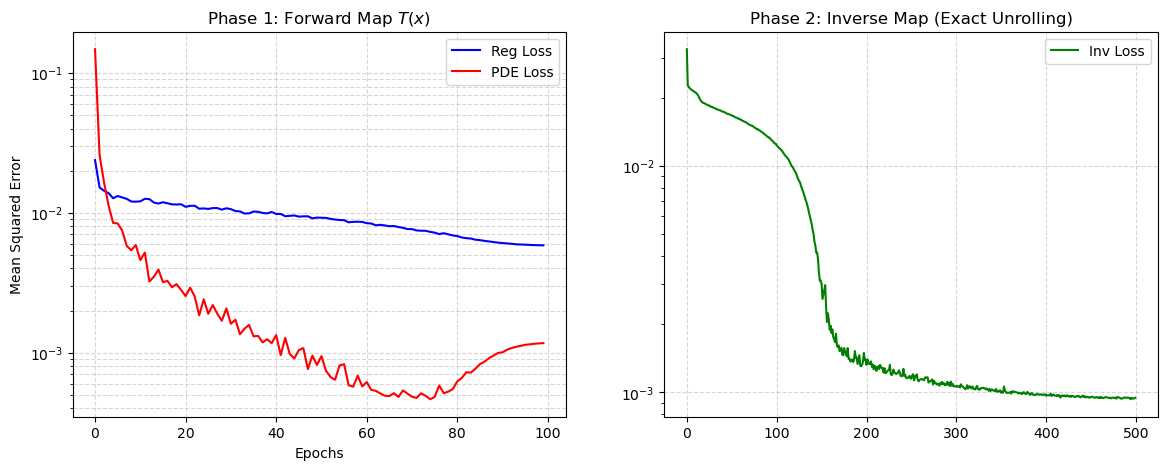

Epoch 499 | Avg Loss: 9.4567e-04 | LR: 1.01e-06

[SAVE] Successfully saved Lorenz models to kkl_models_lorenz.pth

--- Simulating and Plotting Estimation ---


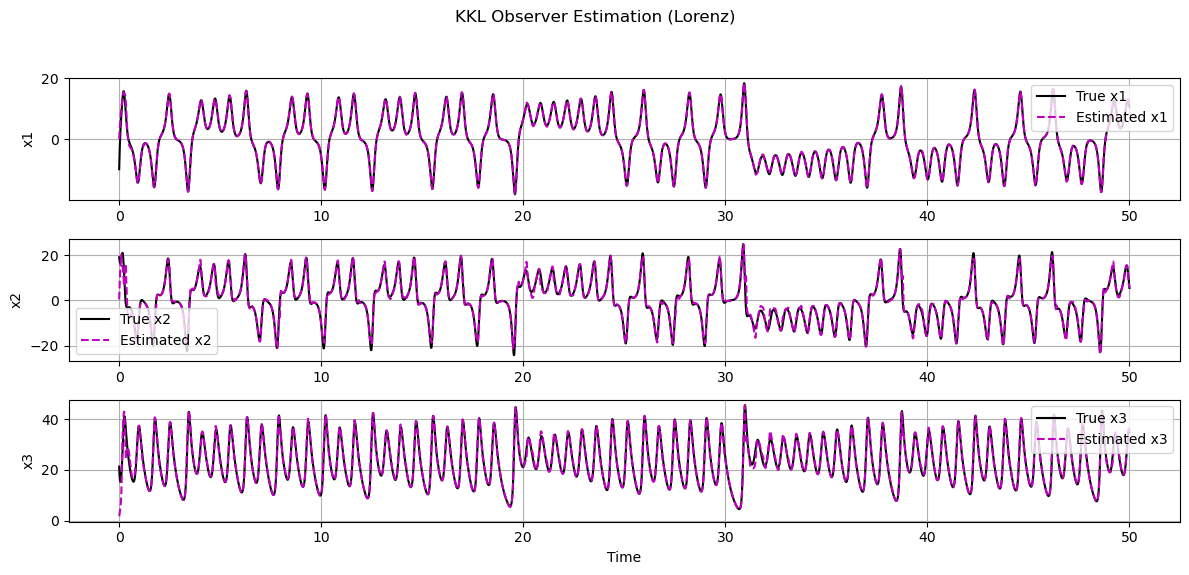


--- SPINN Method's Execution Complete ---


In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = Lorenz()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference


--- Simulating and Plotting Estimation ---


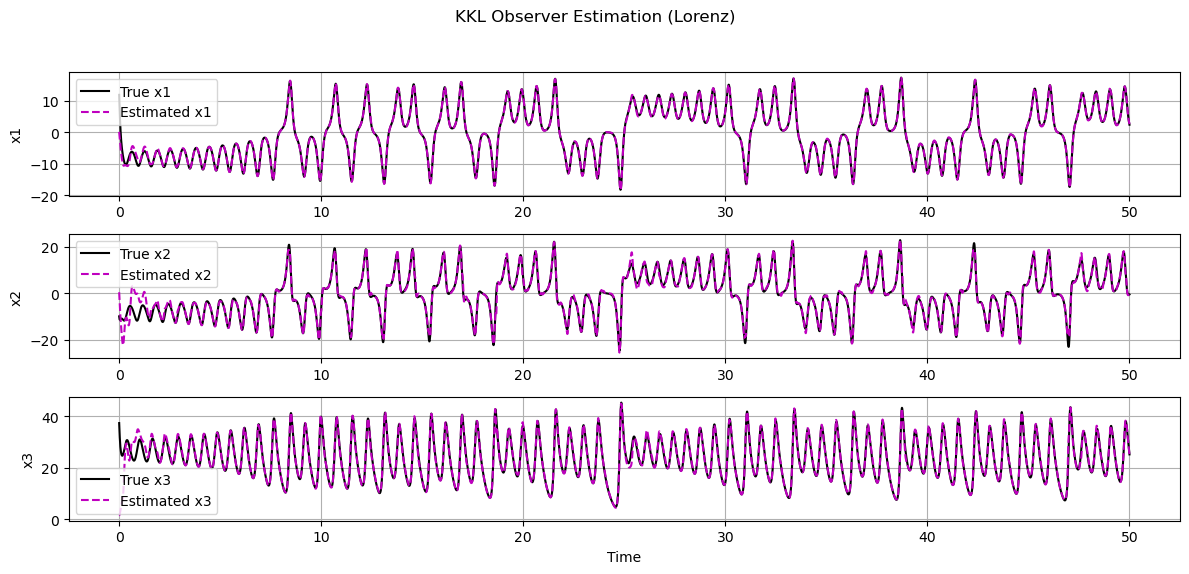


--- SPINN Method's Execution Complete ---


In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = Lorenz()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Chua's circuit

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = ChuasCircuit()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = ChuasCircuit()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Chen's system

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = ChenSystem()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = ChenSystem()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Double pendulum

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = DoublePendulum()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = DoublePendulum()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Swing equation (synchronous machine)

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = SwingEquation()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = SwingEquation()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Kuramoto oscillator network

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = Kuramoto4()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = Kuramoto4()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Bergen-Hill power flow equations

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = BergenHillPowerFlow()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = BergenHillPowerFlow()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Intelligent Driver Model (IDM)

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = IntelligentDriverModel()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = IntelligentDriverModel()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Replicator dynamics

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = ReplicatorDynamics()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = ReplicatorDynamics()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Lotka-Volterra equations

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = LotkaVolterra()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = LotkaVolterra()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Fitz-Hugh-Nagumo model

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = FitzHughNagumo()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = FitzHughNagumo()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## Hodgkin-Huxley model

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = HodgkinHuxley()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = HodgkinHuxley()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

## SEIR model

### Training

In [ ]:
import torch
import torch.nn as nn

print("--- Running SPINN Method ---")

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# --- System Setup ---
system = SEIRModel()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')
z_space_bounds = [(-10, 10)] * n_z

config = {
    'n_trajs': 500,
    'n_points_forward': 1000000,
    'expansion_factor': 2,
    'n_points_inverse': 5000000,      
    't_span': [0, 50],
    'dt': 0.01,
    'epochs1': 150,
    'epochs2': 500,
    'batch_size_1': 1024,
    'batch_size_2': 4096,
    'lr1': 1e-3,               
    'lr2': 1e-3,
    'lambda_reg': 10.0, 
    'lambda_pde': 1.0,
    'hidden_dims': [512, 512, 512, 512],
    'activation1': nn.SiLU(),
    'activation2': nn.SiLU(),
}

model_dict, scaling_params = train_spinn(
    system, A_obs, B_obs, config, z_space_bounds
)

t_net, t_inv_net = model_dict['t_net'], model_dict['t_inv_net']


# --- Create KKL Observer Instance ---
with torch.no_grad():
    # Sample points to estimate y range
    x_samples = sample_x_points(scaling_params['x_min'], scaling_params['x_max'], 1000)
    y_samples = system.h(x_samples)
    scaling_params['y_min'] = y_samples.min(dim=0)[0]
    scaling_params['y_max'] = y_samples.max(dim=0)[0]

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,  # Pass the trained inverse map
    t0=config['t_span'][0],
    tf=config['t_span'][1],
    N=int((config['t_span'][1] - config['t_span'][0]) / config['dt']),
    init_z_zero=True, # Start observer with z(0) = 0
    scaling_params=scaling_params
)

# =====================================================================
# --- Save the Trained Networks and Complete Scaling Parameters ---
# =====================================================================
save_checkpoint = {
    't_net_state_dict': t_net.state_dict(),
    't_inv_net_state_dict': t_inv_net.state_dict(),
    'scaling_params': scaling_params,       
    'hidden_dims': config['hidden_dims'],
    'activation1': config['activation1'],     # Save both activations 
    'activation2': config['activation2']
}

save_path = f"kkl_models_{system.name.lower()}.pth"
torch.save(save_checkpoint, save_path)
print(f"\n[SAVE] Successfully saved {system.name} models to {save_path}")
# =====================================================================

# --- Simulate and Plot Estimation Results ---
ic_test_np = sample_x0(system.x0_space_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")

### Inference

In [ ]:
import torch
import torch.nn as nn
import numpy as np

print("--- Loading SPINN Model for Inference ---")

device = torch.device('cpu') # Forced for fast inference

# --- 1. System Setup ---
system = SEIRModel()
n_x, n_y = system.n_x, system.n_y
n_z = n_y * (2 * n_x + 1)

# Recreate the exact same A and B matrices used during training
A_obs, B_obs = create_observer_matrices(n_z, n_y, system.name, strategy='diagonal')

# --- 2. Load the Checkpoint ---
system_name_lower = system.name.lower()
load_path = f"kkl_models_{system_name_lower}.pth"

# Use map_location=device to safely load regardless of whether it was trained on CPU, CUDA, or MPS
checkpoint = torch.load(load_path, map_location=device, weights_only=False)
print(f"Successfully loaded checkpoint from {load_path}")

# --- 3. Extract the Saved Configuration and Scaling ---
scaling_params = checkpoint['scaling_params']
hidden_dims = checkpoint['hidden_dims']
activation2 = checkpoint['activation2']  # The activation used for the inverse map

# --- 4. Reconstruct the Inverse Map ---
# The Observer only needs the inverse map (T^*) during inference
t_inv_net = MLP(n_z, system.n_x, hidden_dims, activation=activation2).to(device)

# Inject the trained weights
t_inv_net.load_state_dict(checkpoint['t_inv_net_state_dict'])

# Freeze the network for inference
t_inv_net.eval() 
t_inv_net.requires_grad_(False) # Strips away Autograd overhead

# --- 5. Initialize the KKL Observer ---
# Note: config is no longer strictly needed. We just define the time span directly.
t0, tf = 0, 50
dt = 0.01

kkl_observer = Observer(
    system=system,
    A_obs=A_obs,
    B_obs=B_obs,
    net=t_inv_net,
    t0=t0,
    tf=tf,
    N=int((tf - t0) / dt),
    init_z_zero=True,
    scaling_params=scaling_params
)

# --- Simulate and Plot Estimation Results ---

# --- 6. Simulate and Plot ---
# Increase the test X space by a factor
factor = 1
scaled_bounds = [(b_min * factor, b_max * factor) for b_min, b_max in system.x_space_bounds]
# Sample from the new scaled boundaries
ic_test_np = sample_x0(scaled_bounds, n_samples=1)
ic_test_torch = torch.tensor(ic_test_np, dtype=torch.float32).unsqueeze(0).to(device)

print("\n--- Simulating and Plotting Estimation ---")
simulate_and_plot(kkl_observer, ic_test_torch, f"KKL Observer Estimation ({system.name})")

print("\n--- SPINN Method's Execution Complete ---")